# COMP316 – BERT Sentiment Classifier
**Steam Reviews Dataset**

> ⚠️ **Requires NVIDIA GPU with CUDA support.**
>
> This notebook is configured for local execution on a CUDA-enabled GPU (e.g. GTX 1060 6GB).
> It is NOT configured for Google Colab. Do not attempt to run on CPU — training time would
> be prohibitively long (10+ hours vs ~2-3 hours on GPU).
>
> **Before running, verify your environment:**
> ```
> pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
> pip install transformers pandas matplotlib seaborn scikit-learn
> ```
>
> ⚠️ **BERT is large and slow — expect ~2–3 hours training time on a GTX 1060.**

##########################################################
#                 BERT SENTIMENT CLASSIFIER
#                   COMP316 PROJECT
#
# Model:   bert-base-uncased (HuggingFace Transformers)
# Task:    Binary sentiment classification
#          (1 = Positive, 0 = Negative)
#
# Dataset: Steam Reviews
#          - Training:  42,000 reviews (balanced 50/50)
#          - Test:      18,000 reviews (balanced 50/50)
#
# Hardware: Designed for local GPU execution
#           Tested on NVIDIA GTX 1060 6GB (CUDA 11.8)
# This decision was made because of the limitation of
# Google Collab since it would not allow us to
# train on the full 42k. This would invalidate
# out results as it would mean that our BERT
# models was not fairly train on the same
# data as the other 2
#
# This notebook is one of three models evaluated:
#   1. Naive Bayes  (Traditional ML)
#   2. LSTM         (Deep Learning)
#   3. BERT         (Transformer) ← This notebook
#
# All three models use identical train/test splits
# to ensure fair and consistent comparison.
##########################################################

##########################################################
#                 BERT MODEL OVERVIEW
#
# BERT (Bidirectional Encoder Representations from
# Transformers) is a transformer-based language model
# developed by Google (Devlin et al., 2018).
#
# KEY PROPERTIES:
#
# - Bidirectional: reads text left-to-right AND
#   right-to-left simultaneously, capturing full
#   sentence context for each token
#
# - Pre-trained: bert-base-uncased was trained on
#   BooksCorpus + English Wikipedia (3.3B words)
#   using Masked Language Modelling (MLM) and
#   Next Sentence Prediction (NSP)
#
# - Fine-tuned: we adapt the pre-trained weights
#   to our specific sentiment classification task
#   using our Steam review dataset
#
# WHY bert-base-uncased:
#
# - Lowercases all input text automatically
#   (appropriate for informal Steam reviews)
# - Smaller than bert-large (110M vs 340M parameters)
#   making it feasible on consumer GPU hardware
# - Well-established baseline for NLP benchmarks
#
# ARCHITECTURE:
# - 12 transformer layers
# - 12 attention heads
# - 768 hidden dimensions
# - 110M total parameters
##########################################################

## 1. Imports

In [1]:
##########################################################
#                      1. IMPORTS
#
# Core libraries:
#   pandas        → data loading and manipulation
#   numpy         → numerical operations
#   time          → training duration tracking
#   matplotlib    → training history plots
#   seaborn       → confusion matrix visualisation
#
# PyTorch:
#   torch                    → tensor operations + CUDA
#   torch.utils.data         → Dataset and DataLoader
#   torch.optim.AdamW        → optimiser (standard for BERT)
#
# HuggingFace Transformers:
#   BertTokenizer                  → WordPiece tokenisation
#   BertForSequenceClassification  → pre-trained BERT +
#                                    classification head
#   get_linear_schedule_with_warmup → LR scheduler
#
# Scikit-learn:
#   accuracy_score etc → evaluation metrics
##########################################################

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

print('All imports successful.')

All imports successful.


## 2. GPU Verification

In [2]:
##########################################################
#                   2. GPU VERIFICATION
#
# BERT fine-tuning requires a CUDA-enabled GPU.
# Running on CPU is technically possible but would
# take 10+ hours for 42k reviews — not practical.
#
# This block raises an explicit error if CUDA is not
# detected, rather than silently falling back to CPU
# and producing an unusably slow training run.
#
# If this fails, check:
#   1. PyTorch was installed with CUDA support:
#      pip install torch --index-url
#      https://download.pytorch.org/whl/cu118
#   2. NVIDIA drivers are up to date
#   3. Run: nvidia-smi in terminal to verify GPU
##########################################################

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA not detected. Ensure PyTorch is installed with CUDA support.\n"
        "Run: pip install torch --index-url https://download.pytorch.org/whl/cu118"
    )

device = torch.device('cuda')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Using device: {device}')

CUDA available: True
GPU: NVIDIA GeForce GTX 1060
VRAM: 6.4 GB
Using device: cuda


## 3. Configuration

In [3]:
##########################################################
#                   3. CONFIGURATION
#
# DATA PATHS:
#   Update DATA_PATH to the folder containing your
#   cleaned CSV files produced by the preprocessing
#   pipeline. All three model notebooks must point
#   to the same files for a fair comparison.
#
# MODEL PARAMETERS:
#
#   MODEL_NAME = 'bert-base-uncased'
#     Lowercased variant — appropriate for informal
#     Steam reviews where casing is inconsistent.
#
#   MAX_LEN = 128
#     BERT supports up to 512 tokens, but 128 is
#     sufficient for Steam reviews (typically short)
#     and significantly reduces memory usage and
#     training time. Sequences longer than 128 tokens
#     are truncated; shorter sequences are padded.
#
#   BATCH_SIZE = 8
#     Reduced from the standard 16 to fit within the
#     6GB VRAM of the GTX 1060. Each batch of 8
#     reviews is tokenised to MAX_LEN=128 and processed
#     in a single forward/backward pass. Increase to
#     16 only if running on a GPU with 8GB+ VRAM.
#
#   EPOCHS = 3
#     Standard for BERT fine-tuning. The original
#     BERT paper (Devlin et al.) recommends 2-4 epochs
#     for downstream classification tasks. More epochs
#     risk overfitting the pre-trained representations.
#
#   LEARNING_RATE = 2e-5
#     Canonical BERT fine-tuning rate. Higher rates
#     destabilise the pre-trained weights; lower rates
#     slow convergence. 2e-5 is the most widely used
#     value in the literature for classification tasks.
##########################################################

# ========== DATA PATHS ==========
# Update this to the folder containing your CSV files
DATA_PATH = r"C:\Users\Israfeel Yusuf\Documents\COMP316\data"

TRAIN_FILE         = f'{DATA_PATH}/steam_reviews_train.csv'
TEST_NO_SENT_FILE  = f'{DATA_PATH}/steam_reviews_test_NO_SENTIMENT.csv'
TEST_WITH_SENT_FILE= f'{DATA_PATH}/steam_reviews_test_WITH_SENTIMENT.csv'

# ========== MODEL PARAMETERS ==========
MODEL_NAME    = 'bert-base-uncased'
MAX_LEN       = 128
BATCH_SIZE    = 8
EPOCHS        = 3
LEARNING_RATE = 2e-5

print('Configuration loaded.')
print(f'  Model:       {MODEL_NAME}')
print(f'  Max length:  {MAX_LEN} tokens')
print(f'  Batch size:  {BATCH_SIZE}')
print(f'  Epochs:      {EPOCHS}')
print(f'  Learing rate:{LEARNING_RATE}')

Configuration loaded.
  Model:       bert-base-uncased
  Max length:  128 tokens
  Batch size:  8
  Epochs:      3
  Learing rate:2e-05


## 4. Load Data

In [4]:
##########################################################
#                     4. LOAD DATA
#
# Three files are loaded:
#
#   steam_reviews_train_FINAL.csv
#     42,000 reviews with sentiment labels (0 or 1).
#     Used for fine-tuning BERT weights.
#     Balanced: 21,000 positive, 21,000 negative.
#
#   steam_reviews_test_NO_SENTIMENT_FINAL.csv
#     18,000 reviews WITHOUT sentiment labels.
#     Used as input for generating predictions.
#     BERT sees only the review text.
#
#   steam_reviews_test_WITH_SENTIMENT_FINAL.csv
#     18,000 reviews WITH sentiment labels.
#     Used to evaluate prediction accuracy AFTER
#     predictions have been generated.
#     Never exposed to the model during inference.
#
# NOTE ON CONSISTENCY:
#   No subsampling is applied here. BERT trains and
#   evaluates on the full dataset, identical to the
#   Naive Bayes and LSTM notebooks. This ensures
#   all three models are compared on equal footing.
##########################################################

steam_reviews_train_FINAL = r"C:\Users\Israfeel Yusuf\Documents\COMP316\data\steam_reviews_train_FINAL.csv"

steam_reviews_test_NO_SENTIMENT_FINAL = r"C:\Users\Israfeel Yusuf\Documents\COMP316\data\steam_reviews_test_NO_SENTIMENT_FINAL.csv"

steam_reviews_test_WITH_SENTIMENT_FINAL = r"C:\Users\Israfeel Yusuf\Documents\COMP316\data\steam_reviews_test_WITH_SENTIMENT_FINAL.csv"

train_df = pd.read_csv(
    steam_reviews_train_FINAL,
    encoding='utf-8-sig'
)

test_no_sent_df = pd.read_csv(
    steam_reviews_test_NO_SENTIMENT_FINAL,
    encoding='utf-8-sig'
)

test_with_sent_df = pd.read_csv(
    steam_reviews_test_WITH_SENTIMENT_FINAL,
    encoding='utf-8-sig'
)

print('=== DATA LOADED ===')
print(f'Training set:  {len(train_df):,} reviews')
print(f'Test set:      {len(test_no_sent_df):,} reviews')

print()
print('Training sentiment distribution:')
print(train_df['sentiment'].value_counts())

print()
print('Test (with sentiment) distribution:')
print(test_with_sent_df['sentiment'].value_counts())

=== DATA LOADED ===
Training set:  42,000 reviews
Test set:      18,000 reviews

Training sentiment distribution:
sentiment
1    21000
0    21000
Name: count, dtype: int64

Test (with sentiment) distribution:
sentiment
0    9000
1    9000
Name: count, dtype: int64


## 5. Tokenise with BERT Tokenizer

In [5]:
##########################################################
#               5. TOKENISE WITH BERT TOKENIZER
#
# BERT uses WordPiece tokenisation — it splits words
# into subword units (e.g. 'playing' → 'play', '##ing')
# which allows it to handle unknown words gracefully.
#
# Unlike Naive Bayes and LSTM, BERT does NOT require
# manual text cleaning (lowercasing, stopword removal,
# stemming). The tokeniser and pre-trained weights
# handle this implicitly.
#
# TOKENISATION PARAMETERS:
#
#   max_length=MAX_LEN
#     Truncates reviews longer than 128 tokens.
#     Steam reviews are typically short, so very
#     little information is lost.
#
#   padding='max_length'
#     Pads shorter reviews with [PAD] tokens to
#     ensure uniform tensor dimensions within a batch.
#
#   truncation=True
#     Enables truncation for reviews exceeding MAX_LEN.
#
#   attention_mask
#     A binary mask (1 = real token, 0 = padding).
#     Tells BERT which tokens to attend to and which
#     to ignore, preventing padding from influencing
#     the model's representations.
#
# SteamReviewDataset:
#   A custom PyTorch Dataset class that tokenises
#   reviews on-the-fly during DataLoader iteration.
#   Labels are optional — the test dataset has none
#   at inference time.
##########################################################

print(f'Loading {MODEL_NAME} tokenizer...')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded.')


class SteamReviewDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Guard against None or NaN review text
        text = str(self.texts[idx]) if self.texts[idx] is not None else ''

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        item = {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze()
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


# =========================
# BUILD DATASETS
# =========================
train_dataset = SteamReviewDataset(
    texts=train_df['review_text'].tolist(),
    labels=train_df['sentiment'].tolist(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)
test_dataset = SteamReviewDataset(
    texts=test_no_sent_df['review_text'].tolist(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

# =========================
# BUILD DATALOADERS
# =========================
# shuffle=True for training ensures the model does not
# learn the order of the data across epochs.
# shuffle=False for testing ensures predictions align
# with the original row order for evaluation.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader):,}  ({len(train_dataset):,} reviews @ batch size {BATCH_SIZE})')
print(f'Test  batches: {len(test_loader):,}  ({len(test_dataset):,} reviews @ batch size {BATCH_SIZE})')

Loading bert-base-uncased tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\Israfeel Yusuf\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Israfeel Yusuf\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded.
Train batches: 5,250  (42,000 reviews @ batch size 8)
Test  batches: 2,250  (18,000 reviews @ batch size 8)


## 6. Load Pre-trained BERT Model

In [6]:
##########################################################
#             6. LOAD PRE-TRAINED BERT MODEL
#
# BertForSequenceClassification loads the pre-trained
# bert-base-uncased weights and attaches a linear
# classification head on top of the [CLS] token output.
#
# The [CLS] token is a special token prepended to every
# input sequence. After passing through all 12 transformer
# layers, its final hidden state is used as the aggregate
# sequence representation for classification.
#
# num_labels=2 configures the head for binary output:
#   - Output 0 → Negative sentiment
#   - Output 1 → Positive sentiment
#
# The model is moved to the GPU immediately after loading
# to ensure all forward passes occur on CUDA.
##########################################################

print(f'Loading {MODEL_NAME} for sequence classification...')
bert_model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
bert_model = bert_model.to(device)
print(f'Model loaded and moved to: {device}')
print(f'Total parameters: {sum(p.numel() for p in bert_model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in bert_model.parameters() if p.requires_grad):,}')

Loading bert-base-uncased for sequence classification...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded and moved to: cuda
Total parameters: 109,483,778
Trainable parameters: 109,483,778


## 7. Fine-tune BERT

In [7]:
##########################################################
#                   7. FINE-TUNE BERT
#
# OPTIMISER — AdamW:
#   Adam with decoupled weight decay (AdamW) is the
#   standard optimiser for transformer fine-tuning.
#   eps=1e-8 improves numerical stability in the
#   Adam denominator.
#
# LEARNING RATE SCHEDULER — Linear Warmup:
#   The learning rate starts at 0, linearly increases
#   to LEARNING_RATE over the warmup steps (first 10%
#   of training), then linearly decays back to 0.
#
#   Warmup prevents large gradient updates from
#   destabilising pre-trained BERT weights in the
#   early stages of fine-tuning.
#
# GRADIENT CLIPPING (clip_grad_norm_, max=1.0):
#   Caps the norm of the gradient vector at 1.0.
#   This prevents exploding gradients — a known
#   instability risk when fine-tuning large transformer
#   models on small datasets.
#
# TRAINING LOOP:
#   For each batch:
#     1. Zero gradients from previous step
#     2. Forward pass → compute loss + logits
#     3. Backward pass → compute gradients
#     4. Clip gradients
#     5. Update weights (optimiser step)
#     6. Update learning rate (scheduler step)
#
# PROGRESS LOGGING:
#   Loss and accuracy are printed every 200 batches
#   so you can monitor training without waiting for
#   a full epoch to complete.
##########################################################

# =========================
# OPTIMISER AND SCHEDULER
# =========================
optimizer   = AdamW(bert_model.parameters(), lr=LEARNING_RATE, eps=1e-8)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

train_losses = []
train_accs   = []

print(f'Fine-tuning BERT for {EPOCHS} epochs...')
print(f'Total training steps: {total_steps:,}')
print(f'Warmup steps: {int(0.1 * total_steps):,}')
print()

total_start = time.time()

for epoch in range(EPOCHS):
    bert_model.train()
    epoch_loss  = 0
    correct     = 0
    total       = 0
    epoch_start = time.time()

    for i, batch in enumerate(train_loader):
        optimizer.zero_grad()

        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss   = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        preds       = torch.argmax(logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        # Progress update every 200 batches
        if (i + 1) % 200 == 0:
            running_acc = correct / total
            print(f'  Epoch {epoch+1} | Batch {i+1}/{len(train_loader)} | '
                  f'Loss: {loss.item():.4f} | Running Acc: {running_acc:.4f}')

    avg_loss = epoch_loss / len(train_loader)
    acc      = correct / total
    train_losses.append(avg_loss)
    train_accs.append(acc)

    epoch_time = time.time() - epoch_start
    print(f'Epoch {epoch+1}/{EPOCHS} — '
          f'Loss: {avg_loss:.4f} | '
          f'Accuracy: {acc:.4f} | '
          f'Time: {epoch_time:.0f}s ({epoch_time/60:.1f} min)')

training_time = time.time() - total_start
print(f'\nTotal training time: {training_time:.1f}s ({training_time/60:.1f} min)')

Fine-tuning BERT for 3 epochs...
Total training steps: 15,750
Warmup steps: 1,575

  Epoch 1 | Batch 200/5250 | Loss: 0.8425 | Running Acc: 0.5150
  Epoch 1 | Batch 400/5250 | Loss: 0.3307 | Running Acc: 0.6450
  Epoch 1 | Batch 600/5250 | Loss: 0.1886 | Running Acc: 0.7094
  Epoch 1 | Batch 800/5250 | Loss: 0.3398 | Running Acc: 0.7419
  Epoch 1 | Batch 1000/5250 | Loss: 0.4855 | Running Acc: 0.7631
  Epoch 1 | Batch 1200/5250 | Loss: 0.3204 | Running Acc: 0.7760
  Epoch 1 | Batch 1400/5250 | Loss: 0.4655 | Running Acc: 0.7883
  Epoch 1 | Batch 1600/5250 | Loss: 0.7657 | Running Acc: 0.7989
  Epoch 1 | Batch 1800/5250 | Loss: 0.0471 | Running Acc: 0.8063
  Epoch 1 | Batch 2000/5250 | Loss: 0.0777 | Running Acc: 0.8139
  Epoch 1 | Batch 2200/5250 | Loss: 0.0176 | Running Acc: 0.8200
  Epoch 1 | Batch 2400/5250 | Loss: 0.2386 | Running Acc: 0.8249
  Epoch 1 | Batch 2600/5250 | Loss: 0.6213 | Running Acc: 0.8287
  Epoch 1 | Batch 2800/5250 | Loss: 0.5550 | Running Acc: 0.8321
  Epoch 1 |

## 8. Save Model

In [8]:
##########################################################
#                    8. SAVE MODEL
#
# The fine-tuned model and tokeniser are saved to disk
# immediately after training completes.
#
# WHY THIS IS IMPORTANT:
#   BERT training takes 2-3 hours on a GTX 1060.
#   Saving ensures the trained weights are not lost
#   if the kernel restarts or the session ends before
#   inference and evaluation are complete.
#
# The saved model can be reloaded with:
#   BertForSequenceClassification.from_pretrained(
#       './bert_steam_model'
#   )
##########################################################

SAVE_DIR = './bert_steam_model'
bert_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f'Model and tokenizer saved to: {SAVE_DIR}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: ./bert_steam_model


## 9. Training History Plot

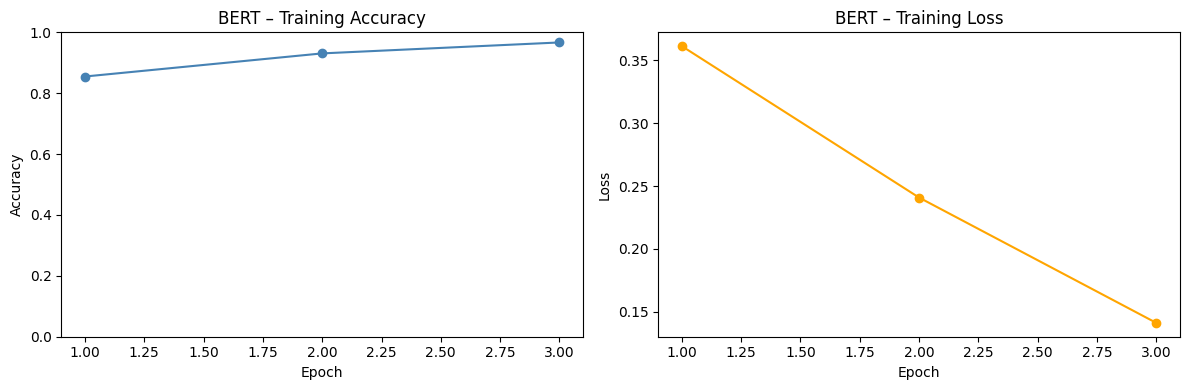

Saved: bert_training_history.png


In [9]:
##########################################################
#               9. TRAINING HISTORY PLOT
#
# Plots training accuracy and loss across epochs.
#
# WHAT TO LOOK FOR:
#   - Accuracy should increase each epoch
#   - Loss should decrease each epoch
#   - If accuracy plateaus or loss increases on epoch
#     3, the model may be starting to overfit
#
# Saved as bert_training_history.png for inclusion
# in the project report.
##########################################################

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, EPOCHS+1), train_accs, marker='o', color='steelblue')
ax1.set_title('BERT – Training Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)

ax2.plot(range(1, EPOCHS+1), train_losses, marker='o', color='orange')
ax2.set_title('BERT – Training Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')

plt.tight_layout()
plt.savefig('bert_training_history.png', dpi=150)
plt.show()
print('Saved: bert_training_history.png')

## 10. Predict on Test Set

In [10]:
##########################################################
#               10. PREDICT ON TEST SET
#
# Predictions are generated on the test set that
# contains NO sentiment labels (test_no_sent_df).
#
# The model only sees review_text — it has no access
# to the true labels during inference.
#
# torch.no_grad():
#   Disables gradient computation during inference.
#   This reduces memory usage and speeds up prediction
#   since we are not backpropagating.
#
# bert_model.eval():
#   Switches the model to evaluation mode, which
#   disables dropout layers that are only active
#   during training.
#
# TRUE LABEL ALIGNMENT:
#   After generating predictions, true labels are
#   retrieved from test_with_sent_df using review_id
#   to ensure correct row-by-row alignment.
#   This is robust to any ordering differences
#   between the two test files.
##########################################################

bert_model.eval()
all_preds = []

print('Generating predictions on test set...')
inference_start = time.time()

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs        = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds          = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

inference_time = time.time() - inference_start
y_pred = np.array(all_preds)
print(f'Inference complete: {len(y_pred):,} predictions in {inference_time:.2f}s')

# =========================
# ALIGN TRUE LABELS
# =========================
# Match ground truth to predictions using review_id
# to guarantee correct alignment regardless of file ordering
y_test_true = (
    test_with_sent_df
    .set_index('review_id')
    .loc[test_no_sent_df['review_id']]['sentiment']
    .values
)

# =========================
# BUILD RESULTS DATAFRAME
# =========================
results_df = test_no_sent_df[['review_id']].copy()
results_df['predicted_sentiment'] = y_pred
results_df['true_sentiment']      = y_test_true

print()
print('Sample predictions:')
print(results_df.head(10).to_string(index=False))

Generating predictions on test set...
Inference complete: 18,000 predictions in 227.74s

Sample predictions:
 review_id  predicted_sentiment  true_sentiment
         1                    0               0
         2                    1               1
         3                    1               1
         4                    0               0
         5                    0               0
         6                    1               1
         7                    1               1
         8                    0               0
         9                    1               1
        10                    1               1


## 11. Evaluate the Model

In [11]:
##########################################################
#                 11. EVALUATE THE MODEL
#
# METRICS USED (consistent across all three models):
#
#   Accuracy:
#     Proportion of correctly classified reviews.
#     Primary metric for balanced datasets.
#
#   Precision:
#     Of all reviews predicted positive, how many
#     actually were? Measures false positive rate.
#
#   Recall:
#     Of all actually positive reviews, how many
#     did the model correctly identify? Measures
#     false negative rate.
#
#   F1-Score:
#     Harmonic mean of precision and recall.
#     Most informative single metric for comparing
#     classification models.
#
# These four metrics are recorded for all three models
# (Naive Bayes, LSTM, BERT) in bert_metrics.csv,
# enabling direct side-by-side comparison in the report.
##########################################################

acc       = accuracy_score(y_test_true, y_pred)
precision = precision_score(y_test_true, y_pred)
recall    = recall_score(y_test_true, y_pred)
f1        = f1_score(y_test_true, y_pred)

print('=' * 50)
print('           BERT EVALUATION RESULTS')
print('=' * 50)
print(f'  Accuracy :    {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision:    {precision:.4f}')
print(f'  Recall   :    {recall:.4f}')
print(f'  F1-Score :    {f1:.4f}')
print(f'  Train Time:   {training_time:.1f}s ({training_time/60:.1f} min)')
print(f'  Inference:    {inference_time:.2f}s ({len(y_pred):,} reviews)')
print('=' * 50)
print()
print('Full Classification Report:')
print(classification_report(
    y_test_true, y_pred,
    target_names=['Negative (0)', 'Positive (1)']
))

           BERT EVALUATION RESULTS
  Accuracy :    0.9030  (90.30%)
  Precision:    0.9045
  Recall   :    0.9011
  F1-Score :    0.9028
  Train Time:   5160.9s (86.0 min)
  Inference:    227.74s (18,000 reviews)

Full Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.90      0.90      0.90      9000
Positive (1)       0.90      0.90      0.90      9000

    accuracy                           0.90     18000
   macro avg       0.90      0.90      0.90     18000
weighted avg       0.90      0.90      0.90     18000



## 12. Confusion Matrix

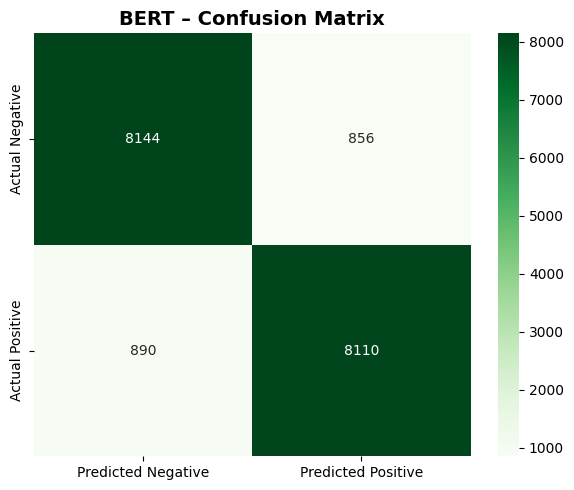

Saved: bert_confusion_matrix.png


In [12]:
##########################################################
#                 12. CONFUSION MATRIX
#
# A confusion matrix shows the breakdown of correct
# and incorrect predictions across both classes:
#
#   True Negative  (TN): Correctly predicted negative
#   False Positive (FP): Incorrectly predicted positive
#   False Negative (FN): Incorrectly predicted negative
#   True Positive  (TP): Correctly predicted positive
#
# Saved as bert_confusion_matrix.png for the report.
# This plot is produced identically across all three
# model notebooks for visual consistency.
##########################################################

cm = confusion_matrix(y_test_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Predicted Negative', 'Predicted Positive'],
    yticklabels=['Actual Negative',    'Actual Positive']
)
plt.title('BERT – Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bert_confusion_matrix.png', dpi=150)
plt.show()
print('Saved: bert_confusion_matrix.png')

## 13. Save Results

In [13]:
##########################################################
#                   13. SAVE RESULTS
#
# Two output files are produced:
#
#   bert_predictions.csv
#     Full prediction output: review_id,
#     predicted_sentiment, and true_sentiment
#     for every review in the test set.
#
#   bert_metrics.csv
#     Summary metrics for this model. Formatted
#     identically to the output of the Naive Bayes
#     and LSTM notebooks so all three can be combined
#     into a single comparison table in the report.
##########################################################

# =========================
# SAVE PREDICTIONS
# =========================
results_df.to_csv('bert_predictions.csv', index=False, encoding='utf-8-sig')
print('Predictions saved: bert_predictions.csv')

# =========================
# SAVE METRICS
# =========================
metrics_df = pd.DataFrame([{
    'Model'            : 'BERT',
    'Accuracy'         : round(acc, 4),
    'Precision'        : round(precision, 4),
    'Recall'           : round(recall, 4),
    'F1_Score'         : round(f1, 4),
    'Train_Time_s'     : round(training_time, 2),
    'Inference_Time_s' : round(inference_time, 2),
    'Train_Samples'    : len(train_df),
    'Test_Samples'     : len(test_no_sent_df)
}])
metrics_df.to_csv('bert_metrics.csv', index=False)
print('Metrics saved:     bert_metrics.csv')
print()
print(metrics_df.to_string(index=False))

Predictions saved: bert_predictions.csv
Metrics saved:     bert_metrics.csv

Model  Accuracy  Precision  Recall  F1_Score  Train_Time_s  Inference_Time_s  Train_Samples  Test_Samples
 BERT     0.903     0.9045  0.9011    0.9028       5160.94            227.74          42000         18000
